In [8]:
# Run once. Restart kernel after if prompted.
import subprocess, sys

packages = [
    'pandas', 'numpy', 'scipy', 'scikit-learn',
    'xgboost', 'shap', 'imbalanced-learn',
    'geopandas', 'libpysal', 'esda',
    'matplotlib', 'seaborn', 'openpyxl',
    'statsmodels', 'joblib',
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
    print(f'  OK: {pkg}')
print('All packages installed.')

  OK: pandas
  OK: numpy
  OK: scipy
  OK: scikit-learn
  OK: xgboost
  OK: shap
  OK: imbalanced-learn
  OK: geopandas
  OK: libpysal
  OK: esda
  OK: matplotlib
  OK: seaborn
  OK: openpyxl
  OK: statsmodels
  OK: joblib
All packages installed.


In [10]:
# ================================================================
# CELL 2: ALL IMPORTS AND PROJECT CONFIGURATION
# ================================================================
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os, zipfile, warnings
from pathlib import Path
from scipy.stats import zscore
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.4f}'.format)

# ---- Project Paths -----------------------------------------
# Change BASE_DIR to match where you created the folder structure
BASE_DIR = Path('credit_desert_project')   # <-- UPDATE THIS PATH

RAW         = BASE_DIR / 'data/raw'
PROCESSED   = BASE_DIR / 'data/processed'
TABLEAU_OUT = BASE_DIR / 'data/tableau_exports'
MODELS_DIR  = BASE_DIR / 'models'
OUTPUTS     = BASE_DIR / 'outputs'

# Create all directories if they don't exist
for d in [RAW/'hmda', RAW/'acs', RAW/'ffiec', RAW/'fdic',
          RAW/'bls', RAW/'irs', RAW/'shapefiles',
          PROCESSED, TABLEAU_OUT, MODELS_DIR, OUTPUTS]:
    d.mkdir(parents=True, exist_ok=True)

# ---- Target States -----------------------------------------
# FIPS codes for our 8 states
TARGET_STATE_NAMES  = ['CA','FL','GA','IL','MI','NY','OH','TX']
TARGET_STATE_FIPS   = ['06','12','13','17','26','36','39','48']
TARGET_STATE_FIPS_INT = [6, 12, 13, 17, 26, 36, 39, 48]

print('Configuration loaded.')
print(f'Base directory: {BASE_DIR.resolve()}')
print(f'Target states : {TARGET_STATE_NAMES}')


Configuration loaded.
Base directory: C:\Users\Amirh\OneDrive - Wright State University\Research\Inclusive Lending\credit_desert_project
Target states : ['CA', 'FL', 'GA', 'IL', 'MI', 'NY', 'OH', 'TX']


In [12]:
# ================================================================
# CELL 3: UNZIP SHAPEFILES (Run Once)
# ================================================================
import zipfile

shp_zips = {
    'CA': RAW / 'shapefiles/tl_2022_06_tract.zip',
    'FL': RAW / 'shapefiles/tl_2022_12_tract.zip',
    'GA': RAW / 'shapefiles/tl_2022_13_tract.zip',
    'IL': RAW / 'shapefiles/tl_2022_17_tract.zip',
    'MI': RAW / 'shapefiles/tl_2022_26_tract.zip',
    'NY': RAW / 'shapefiles/tl_2022_36_tract.zip',
    'OH': RAW / 'shapefiles/tl_2022_39_tract.zip',
    'TX': RAW / 'shapefiles/tl_2022_48_tract.zip',
}

for state, zip_path in shp_zips.items():
    out_dir = RAW / f'shapefiles/tl_2022_{zip_path.stem[-9:-6]}_tract'
    if not out_dir.exists():
        out_dir.mkdir(parents=True, exist_ok=True)
        if zip_path.exists():
            with zipfile.ZipFile(zip_path, 'r') as zf:
                zf.extractall(out_dir)
            print(f'  Unzipped {state}: {zip_path.name} -> {out_dir.name}/')
        else:
            print(f'  WARNING: {zip_path} not found. Place the zip file there.')
    else:
        print(f'  {state}: already unzipped.')

print('Shapefile extraction complete.')


  CA: already unzipped.
  FL: already unzipped.
  GA: already unzipped.
  IL: already unzipped.
  MI: already unzipped.
  NY: already unzipped.
  OH: already unzipped.
  TX: already unzipped.
Shapefile extraction complete.


In [14]:
# ================================================================
# CELL 4: ACS DATA LOADING
# CRITICAL FIXES APPLIED:
#   1. skiprows=[1]  -> skips the descriptor row (not data, not header)
#   2. BOM stripping -> removes ï»¿ from GEO_ID column name
#   3. Sentinel replacement -> Census uses -666666666 for null/NA
#   4. GEO_ID parsing -> extracts 11-digit tract FIPS from full GEO_ID string
# ================================================================

def load_acs(filename, rename_map):
    """
    Load a Census ACS data CSV with proper BOM and descriptor-row handling.
    rename_map: dict mapping original col names to clean names.
    Returns a DataFrame with 'census_tract_fips' as the join key.
    """
    path = RAW / f'acs/{filename}'
    if not path.exists():
        raise FileNotFoundError(f'Missing ACS file: {path}')

    # Read: row 0 = column headers, row 1 = human-readable descriptor (SKIP)
    df = pd.read_csv(path, header=0, skiprows=[1],
                     encoding='latin1', low_memory=False)

    # Aggressively strip Census garbage characters and quotes from column names
    df.columns = [
        c.replace('ï»¿', '').replace('"', '').strip()
        for c in df.columns
    ]

    # Replace Census null sentinel -666666666 with NaN
    df.replace(-666666666, np.nan, inplace=True)

    # Build 11-digit census tract FIPS from GEO_ID
    # GEO_ID format: '1400000US06001400100'  (last 11 chars = tract FIPS)
    if 'GEO_ID' in df.columns:
        df['census_tract_fips'] = df['GEO_ID'].str[-11:].str.zfill(11)
    else:
        raise KeyError(f'GEO_ID column not found in {filename}. Columns: {list(df.columns[:5])}')

    # Rename to human-readable names
    df = df.rename(columns=rename_map)

    # Keep only the columns we need
    keep = ['census_tract_fips'] + list(rename_map.values())
    keep = [c for c in keep if c in df.columns]
    return df[keep]


# ---- B19013: Median Household Income -----------------------
acs_income = load_acs('ACSDT5Y2022_B19013-Data.csv', {
    'B19013_001E': 'median_hh_income',
})
acs_income['median_hh_income'] = pd.to_numeric(acs_income['median_hh_income'], errors='coerce')
print(f'ACS Income: {len(acs_income):,} tracts | nulls: {acs_income["median_hh_income"].isna().sum():,}')

# ---- B03002: Race / Ethnicity ------------------------------
acs_race = load_acs('ACSDT5Y2022_B03002-Data.csv', {
    'B03002_001E': 'total_pop',
    'B03002_003E': 'white_nh',          # White, not Hispanic/Latino
    'B03002_004E': 'black_nh',           # Black, not Hispanic
    'B03002_006E': 'asian_nh',           # Asian, not Hispanic
    'B03002_012E': 'hispanic_any',       # Hispanic/Latino, any race
    'B03002_005E': 'native_american_nh', # American Indian
})
for col in ['total_pop','white_nh','black_nh','asian_nh','hispanic_any','native_american_nh']:
    acs_race[col] = pd.to_numeric(acs_race[col], errors='coerce')
acs_race['minority_pct'] = np.where(
    acs_race['total_pop'] > 0,
    1 - (acs_race['white_nh'] / acs_race['total_pop']),
    np.nan
)
acs_race['hispanic_pct'] = np.where(
    acs_race['total_pop'] > 0,
    acs_race['hispanic_any'] / acs_race['total_pop'],
    np.nan
)
print(f'ACS Race: {len(acs_race):,} tracts | minority_pct mean: {acs_race["minority_pct"].mean():.3f}')

# ---- B25003: Housing Tenure --------------------------------
acs_tenure = load_acs('ACSDT5Y2022_B25003-Data.csv', {
    'B25003_001E': 'total_housing_units',
    'B25003_002E': 'owner_occupied',
    'B25003_003E': 'renter_occupied',
})
for col in ['total_housing_units','owner_occupied','renter_occupied']:
    acs_tenure[col] = pd.to_numeric(acs_tenure[col], errors='coerce')
acs_tenure['homeownership_rate'] = np.where(
    acs_tenure['total_housing_units'] > 0,
    acs_tenure['owner_occupied'] / acs_tenure['total_housing_units'],
    np.nan
)
print(f'ACS Tenure: {len(acs_tenure):,} tracts | homeown mean: {acs_tenure["homeownership_rate"].mean():.3f}')

# ---- B15003: Educational Attainment ------------------------
acs_edu = load_acs('ACSDT5Y2022_B15003-Data.csv', {
    'B15003_001E': 'pop_25plus',
    'B15003_022E': 'bachelors',
    'B15003_023E': 'masters',
    'B15003_024E': 'professional',
    'B15003_025E': 'doctorate',
})
for col in ['pop_25plus','bachelors','masters','professional','doctorate']:
    acs_edu[col] = pd.to_numeric(acs_edu[col], errors='coerce')
acs_edu['college_plus_pct'] = np.where(
    acs_edu['pop_25plus'] > 0,
    (acs_edu[['bachelors','masters','professional','doctorate']].sum(axis=1)
     / acs_edu['pop_25plus']),
    np.nan
)
print(f'ACS Education: {len(acs_edu):,} tracts | college+ mean: {acs_edu["college_plus_pct"].mean():.3f}')


ACS Income: 38,842 tracts | nulls: 1,028
ACS Race: 38,842 tracts | minority_pct mean: 0.492
ACS Tenure: 38,842 tracts | homeown mean: 0.621
ACS Education: 38,842 tracts | college+ mean: 0.330


In [16]:
# ================================================================
# CELL 5: FFIEC / BLS / IRS / FDIC DATA LOADING
# ================================================================

# ---- FFIEC Census Flat File (2020) -------------------------
# This file has NO header row — all 1,247 columns are positional
# Based on official FFIEC 2020 Census Flat File layout document
# Key columns (0-indexed):
#   0=year, 1=MSA_MD, 2=state_fips, 3=county_fips, 4=tract,
#   10=msa_fam_income, 12=tract_to_msa_income_pct,
#   13=tract_median_family_income, 31=minority_pop_pct

FFIEC_COL_MAP = {
    0: 'ffiec_year',
    1: 'msa_md_code',
    2: 'state_fips_ffiec',
    3: 'county_fips_ffiec',
    4: 'tract_code_ffiec',
    10: 'msa_median_family_income',
    12: 'tract_to_msa_income_pct',
    13: 'tract_median_family_income',
    31: 'ffiec_minority_pct',
}

df_ffiec_raw = pd.read_csv(
    RAW / 'ffiec/CensusFlatFile2020.csv',
    header=None,           # No column headers in this file
    encoding='latin1',
    low_memory=False,
    usecols=list(FFIEC_COL_MAP.keys()),
)
df_ffiec_raw = df_ffiec_raw.rename(columns=FFIEC_COL_MAP)

# Convert to numeric and build FIPS join key
for col in ['state_fips_ffiec','county_fips_ffiec','tract_code_ffiec']:
    df_ffiec_raw[col] = pd.to_numeric(df_ffiec_raw[col], errors='coerce')

# Build 11-digit census_tract_fips: state(2) + county(3) + tract(6)
# FFIEC tract is 6 digits (no decimal), HMDA tract is 11 digits
df_ffiec_raw['state_str']  = df_ffiec_raw['state_fips_ffiec'].fillna(0).astype(int).astype(str).str.zfill(2)
df_ffiec_raw['county_str'] = df_ffiec_raw['county_fips_ffiec'].fillna(0).astype(int).astype(str).str.zfill(3)
df_ffiec_raw['tract_str']  = df_ffiec_raw['tract_code_ffiec'].fillna(0).astype(int).astype(str).str.zfill(6)
df_ffiec_raw['census_tract_fips'] = (df_ffiec_raw['state_str']
                                     + df_ffiec_raw['county_str']
                                     + df_ffiec_raw['tract_str'])

# Filter to our 8 states
df_ffiec = df_ffiec_raw[
    df_ffiec_raw['state_fips_ffiec'].isin(TARGET_STATE_FIPS_INT)
].copy()

# Convert income fields to numeric
for col in ['msa_median_family_income','tract_to_msa_income_pct',
            'tract_median_family_income','ffiec_minority_pct']:
    df_ffiec[col] = pd.to_numeric(df_ffiec[col], errors='coerce')

# LMI flag: tract income < 80% of area median income
df_ffiec['is_lmi_tract'] = (df_ffiec['tract_to_msa_income_pct'] < 80).astype(int)

df_ffiec = df_ffiec[['census_tract_fips','msa_md_code','msa_median_family_income',
                      'tract_to_msa_income_pct','tract_median_family_income',
                      'ffiec_minority_pct','is_lmi_tract']].drop_duplicates('census_tract_fips')

print(f'FFIEC: {len(df_ffiec):,} tracts for 8 states')
print(f'  LMI tracts: {df_ffiec["is_lmi_tract"].sum():,} ({df_ffiec["is_lmi_tract"].mean():.1%})')

# ---- BLS LAUS: County Unemployment -------------------------
# Header is on row index 4 of the Excel file (5th row visually)
df_bls_raw = pd.read_excel(RAW / 'bls/laucnty22.xlsx', header=4, engine='openpyxl')

# Assign clean column names (9 columns in this file)
df_bls_raw.columns = [
    'laus_code', 'state_fips', 'county_fips',
    'county_name', 'year', 'labor_force',
    'employed', 'unemployed', 'unemployment_rate'
]

# Drop rows where state_fips is missing (footer rows in original Excel)
df_bls = df_bls_raw.dropna(subset=['state_fips']).copy()
df_bls['state_fips']  = df_bls['state_fips'].astype(float).astype(int).astype(str).str.zfill(2)
df_bls['county_fips'] = df_bls['county_fips'].astype(float).astype(int).astype(str).str.zfill(3)
df_bls['county_fips_full'] = df_bls['state_fips'] + df_bls['county_fips']
df_bls['unemployment_rate'] = pd.to_numeric(df_bls['unemployment_rate'], errors='coerce')

df_bls = df_bls[df_bls['state_fips'].isin(TARGET_STATE_FIPS)][[
    'county_fips_full','unemployment_rate'
]].drop_duplicates('county_fips_full')

print(f'BLS LAUS: {len(df_bls):,} counties for 8 states')

# ---- IRS SOI: ZIP-Level Income -----------------------------
# IMPORTANT: agi_stub 1-6 are income brackets. There is NO stub=0 total.
# We SUM across all stubs to get total returns and total AGI per ZIP.
# zipcode == 0 are STATE TOTALS — exclude them.
df_irs_raw = pd.read_csv(RAW / 'irs/22zpallagi.csv', low_memory=False)

df_irs = (
    df_irs_raw[
        (df_irs_raw['STATE'].isin(TARGET_STATE_NAMES)) &
        (df_irs_raw['zipcode'] != 0)   # Exclude state-level total rows
    ]
    .groupby(['STATE','zipcode'])
    .agg(
        total_tax_returns=('N1', 'sum'),
        total_agi_thousands=('A00100', 'sum'),
    )
    .reset_index()
)
# Convert AGI from $1,000s to dollars; compute average
df_irs['avg_agi_dollars'] = (
    (df_irs['total_agi_thousands'] * 1000) /
    df_irs['total_tax_returns'].replace(0, np.nan)
)
df_irs['zipcode'] = df_irs['zipcode'].astype(str).str.zfill(5)

print(f'IRS SOI: {len(df_irs):,} ZIP codes for 8 states')
print(f'  avg_agi range: ${df_irs["avg_agi_dollars"].min():,.0f} - ${df_irs["avg_agi_dollars"].max():,.0f}')

# ---- FDIC SOD: Bank Branch Density -------------------------
# IMPORTANT: You need the FULL download with ZIPBR and DEPDOM columns
# If you only have the 7-column custom download, this cell will raise an error
fdic_path = RAW / 'fdic/fdic_sod_2022_FULL.csv'

if not fdic_path.exists():
    print('WARNING: Full FDIC file not found. Skipping branch density.')
    print('Please download from: https://banks.data.fdic.gov/api/branches')
    print('See Part 3 of the setup guide for full instructions.')
    df_fdic_tract = None
else:
    df_fdic_raw = pd.read_csv(fdic_path, encoding='latin1', low_memory=False)
    df_fdic_raw.columns = [c.lstrip('\ufeff').strip().strip('"') for c in df_fdic_raw.columns]

    # Verify required columns exist
    required_fdic_cols = ['ZIPBR', 'STALPBR']
    missing = [c for c in required_fdic_cols if c not in df_fdic_raw.columns]
    if missing:
        raise ValueError(f'FDIC file is missing required columns: {missing}. Re-download the full file.')

    df_fdic_raw = df_fdic_raw[df_fdic_raw['STALPBR'].isin(TARGET_STATE_NAMES)].copy()
    df_fdic_raw['ZIPBR'] = df_fdic_raw['ZIPBR'].astype(str).str.zfill(5)

    # Count branches per ZIP code
    fdic_zip = df_fdic_raw.groupby('ZIPBR').agg(
        branch_count=('ZIPBR','count'),
        total_deposits=('DEPDOM','sum') if 'DEPDOM' in df_fdic_raw.columns else ('ZIPBR','count'),
    ).reset_index().rename(columns={'ZIPBR':'zipcode'})

    # Map ZIP -> Census Tract via HUD crosswalk
    df_cw = pd.read_excel(RAW / 'fdic/ZIP_TRACT_122022.xlsx', engine='openpyxl')
    df_cw['ZIP']   = df_cw['ZIP'].astype(str).str.zfill(5)
    df_cw['TRACT'] = df_cw['TRACT'].astype(str).str.zfill(11)

    fdic_mapped = df_cw.merge(fdic_zip, left_on='ZIP', right_on='zipcode', how='left')
    fdic_mapped['branch_count'] = fdic_mapped['branch_count'].fillna(0)
    fdic_mapped['weighted_branches'] = fdic_mapped['branch_count'] * fdic_mapped['RES_RATIO']

    df_fdic_tract = (
        fdic_mapped.groupby('TRACT')['weighted_branches']
        .sum().reset_index()
        .rename(columns={'TRACT':'census_tract_fips','weighted_branches':'bank_branch_density'})
    )
    print(f'FDIC branches mapped to {len(df_fdic_tract):,} tracts')
    print(f'  Mean branches per tract: {df_fdic_tract["bank_branch_density"].mean():.2f}')


FFIEC: 33,741 tracts for 8 states
  LMI tracts: 11,680 (34.6%)
BLS LAUS: 873 counties for 8 states
IRS SOI: 9,332 ZIP codes for 8 states
  avg_agi range: $19,658 - $4,403,678
FDIC branches mapped to 73,472 tracts
  Mean branches per tract: 0.43


In [18]:
# ================================================================
# CELL 6 [CORRECTED]: HMDA DATA LOADING & OUTLIER REMOVAL
# FIXES: (a) income winsorization, (b) thin_file_proxy de-leaked,
#        (c) action_taken dropped, (d) quarantined model file saved
# ================================================================

HMDA_USECOLS = [
    'census_tract', 'action_taken', 'loan_purpose',
    'loan_type', 'property_type', 'occupancy_type',
    'loan_amount', 'income', 'interest_rate',
    'derived_race', 'derived_ethnicity', 'derived_sex',
    'applicant_age', 'denial_reason-1', 'denial_reason-2',
    'lei', 'state_code', 'county_code', 'activity_year',
    'tract_population',
    'tract_minority_population_percent',
    'ffiec_msa_md_median_family_income',
    'tract_to_msa_income_percentage',
]

hmda_files = list((RAW / 'hmda').glob('*.csv'))
print(f'Found {len(hmda_files)} HMDA file(s)')
if not hmda_files:
    raise FileNotFoundError('No HMDA CSV in data/raw/hmda/')

frames = []
for f in hmda_files:
    print(f'  Loading {f.name}...', end=' ')
    _df = pd.read_csv(f, usecols=lambda c: c in HMDA_USECOLS,
                      low_memory=False, encoding='latin1',
                      dtype={'census_tract': str, 'county_code': str, 'state_code': str})
    print(f'{len(_df):,} rows')
    frames.append(_df)

hmda_raw = pd.concat(frames, ignore_index=True)
n_raw = len(hmda_raw)
print(f'Total raw rows: {n_raw:,}')

# --- Filter: home purchase, owner-occupied, originated or denied ---
hmda = hmda_raw[
    (hmda_raw['loan_purpose'] == 1) &
    (hmda_raw['action_taken'].isin([1, 3])) &
    (hmda_raw['occupancy_type'] == 1)
].copy()
print(f'After purpose/action filter: {len(hmda):,}')

# --- Census tract FIPS ---
hmda['census_tract_fips'] = hmda['census_tract'].str.strip().str.zfill(11)

# --- Target variable ---
hmda['approved'] = (hmda['action_taken'] == 1).astype(int)

# ================================================================
# FIX 1: INCOME OUTLIER REMOVAL
# income in HMDA is in $1,000s. Convert first, then winsorize.
# ================================================================
hmda['income_dollars'] = pd.to_numeric(hmda['income'], errors='coerce') * 1000

# Step 1: Remove biologically impossible negatives
n_before = len(hmda)
hmda = hmda[hmda['income_dollars'].isna() | (hmda['income_dollars'] >= 0)].copy()
print(f'Removed {n_before - len(hmda):,} negative income records')

# Step 2: Winsorize income to [0.5th, 99.5th] percentile
inc_lo = hmda['income_dollars'].quantile(0.005)
inc_hi = hmda['income_dollars'].quantile(0.995)
hmda['income_dollars'] = hmda['income_dollars'].clip(lower=inc_lo, upper=inc_hi)
print(f'Income winsorized to [{inc_lo:,.0f}, {inc_hi:,.0f}]')

# --- Financial ratios ---
hmda['loan_amount']  = pd.to_numeric(hmda['loan_amount'], errors='coerce')
hmda['interest_rate']= pd.to_numeric(hmda['interest_rate'], errors='coerce')
hmda['ffiec_ami']    = pd.to_numeric(hmda['ffiec_msa_md_median_family_income'], errors='coerce')
hmda['tract_to_ami'] = pd.to_numeric(hmda['tract_to_msa_income_percentage'], errors='coerce')

hmda['income_to_ami_ratio'] = hmda['income_dollars'] / hmda['ffiec_ami'].replace(0, np.nan)

# ================================================================
# FIX 2: INCOME_TO_AMI_RATIO OUTLIER REMOVAL
# Valid range for home-purchase applicants: 0 to 20x AMI
# Remove: ratio < 0 (already handled above via income clip)
# Remove: ratio > 20 (implausible; these 157 records are likely data errors)
# ================================================================
n_before = len(hmda)
valid_ratio = (
    hmda['income_to_ami_ratio'].isna() |
    ((hmda['income_to_ami_ratio'] >= 0) & (hmda['income_to_ami_ratio'] <= 20))
)
hmda = hmda[valid_ratio].copy()
print(f'Removed {n_before - len(hmda):,} records with invalid income_to_ami_ratio (>20 or <0)')
print(f'income_to_ami_ratio range: [{hmda["income_to_ami_ratio"].min():.3f}, {hmda["income_to_ami_ratio"].max():.3f}]')

# --- LMI applicant flag ---
hmda['is_lmi_applicant'] = (hmda['income_to_ami_ratio'] < 0.80).astype(int)

# --- Protected class flags ---
MINORITY_RACES = ['Black or African American','Asian',
                  'American Indian or Alaska Native',
                  'Native Hawaiian or Other Pacific Islander',
                  '2 or more minority races']
hmda['is_minority_race']   = hmda['derived_race'].isin(MINORITY_RACES).astype(int)
hmda['is_hispanic'] = (hmda['derived_ethnicity'] == 'Hispanic or Latino').astype(int)
hmda['is_protected_class'] = (
    (hmda['is_minority_race']==1) | (hmda['is_hispanic']==1)).astype(int)

# ================================================================
# FIX 3: THIN_FILE_PROXY — REMOVE approved==0 CLAUSE
# Original: used 'approved==0' which is the target → data leakage
# Corrected: use ONLY denial reason codes 1 (credit history) and
# 8 (credit score) as proxy for thin-file characteristics.
# This proxy is now valid for EDA/description but still excluded
# from model features (it's a derived label, not a predictive signal).
# ================================================================
dr1 = hmda['denial_reason-1'].astype(str).str.strip()
dr2 = hmda['denial_reason-2'].astype(str).str.strip()
hmda['thin_file_proxy'] = (
    dr1.isin(['1','8']) | dr2.isin(['1','8'])
).astype(int)

# Validate: thin_file_proxy should NOT be perfectly correlated with approved
corr_check = hmda['thin_file_proxy'].corr(hmda['approved'])
print(f'thin_file_proxy corr with approved (should be < 0.3): {corr_check:.4f}')
if abs(corr_check) > 0.40:
    print('WARNING: Correlation still high — check denial_reason field name in your HMDA file')
else:
    print('thin_file_proxy leakage check PASSED')

# ================================================================
# FIX 4: DROP action_taken BEFORE SAVING
# action_taken is the SOURCE of the target. Keeping it in the file
# is a latent leakage risk for any future model run.
# ================================================================
DROP_FROM_MODEL = ['action_taken']

# Save FULL research file (with all columns for EDA purposes)
hmda.to_parquet(PROCESSED / 'hmda_clean_full.parquet', index=False)
print('Full HMDA saved (includes action_taken for EDA)')

# Save QUARANTINED MODELING FILE (safe for ML pipeline)
# Exclude: action_taken, denial_reason cols, thin_file_proxy
# These all encode the outcome or are derived from it
LEAKAGE_COLS = ['action_taken', 'denial_reason-1', 'denial_reason-2',
                'denial_reason-1', 'denial_reason-2', 'thin_file_proxy']
model_safe_cols = [c for c in hmda.columns if c not in LEAKAGE_COLS]
hmda_model = hmda[model_safe_cols].copy()
hmda_model.to_parquet(PROCESSED / 'hmda_clean_model_safe.parquet', index=False)
print(f'Model-safe HMDA saved: {len(hmda_model):,} rows')
print(f'Overall approval rate: {hmda["approved"].mean():.1%}')
print(f'Protected class share: {hmda["is_protected_class"].mean():.1%}')


Found 1 HMDA file(s)
  Loading state_TX-IL-OH-NY-CA-GA-FL-MI.csv... 5,225,598 rows
Total raw rows: 5,225,598
After purpose/action filter: 1,578,794
Removed 593 negative income records
Income winsorized to [0, 1,158,000]
Removed 14 records with invalid income_to_ami_ratio (>20 or <0)
income_to_ami_ratio range: [0.000, 19.511]
thin_file_proxy corr with approved (should be < 0.3): -0.5793
Full HMDA saved (includes action_taken for EDA)
Model-safe HMDA saved: 1,578,187 rows
Overall approval rate: 84.4%
Protected class share: 38.8%


In [119]:
# ================================================================
# CELL 7: TRACT-LEVEL AGGREGATION & MASTER DATASET ASSEMBLY
# Join: HMDA + ACS + FFIEC + BLS + IRS + FDIC
# Output: one row per census tract (11-digit FIPS)
# ================================================================

# ---- Step 7a: Aggregate HMDA to Tract Level ----------------
print('Aggregating HMDA to tract level...')

# Overall tract-level statistics
tract_overall = hmda.groupby('census_tract_fips').agg(
    total_applications=('approved', 'count'),
    total_approved=('approved', 'sum'),
    total_denied=('approved', lambda x: (x == 0).sum()),
    median_loan_amount=('loan_amount', 'median'),
    median_income_dollars=('income_dollars', 'median'),
    mean_income_to_ami=('income_to_ami_ratio', 'mean'),
    thin_file_applications=('thin_file_proxy', 'sum'),
    lmi_applicants=('is_lmi_applicant', 'sum'),
    hmda_minority_pct=('tract_minority_population_percent', 'mean'),
    hmda_tract_to_ami=('tract_to_ami', 'mean'),
).reset_index()

tract_overall['denial_rate'] = (
    tract_overall['total_denied'] / 
    tract_overall['total_applications'].replace(0, np.nan)
)

# Approval rates by protected class status
prot_rates = hmda.groupby(['census_tract_fips','is_protected_class'])['approved'].mean().unstack()
prot_rates.columns = ['nonprotected_approval_rate','protected_class_approval_rate']
prot_rates = prot_rates.reset_index()
prot_rates['disparate_impact_ratio'] = (
    prot_rates['protected_class_approval_rate'] /
    prot_rates['nonprotected_approval_rate'].replace(0, np.nan)
)

hmda_tract = tract_overall.merge(prot_rates, on='census_tract_fips', how='left')
print(f'HMDA tract aggregation: {len(hmda_tract):,} tracts')

# ---- Step 7b: Build County FIPS for BLS Join ---------------
hmda_tract['county_fips_full'] = hmda_tract['census_tract_fips'].str[:5]

# ---- Step 7c: Sequential Left Joins ------------------------
print('Building master dataset...')

master = hmda_tract.copy()

# Join ACS Income
master = master.merge(acs_income, on='census_tract_fips', how='left')
print(f'  After ACS income join: {len(master):,} tracts, {master["median_hh_income"].isna().sum()} income nulls')

# Join ACS Race
master = master.merge(acs_race[['census_tract_fips','total_pop','minority_pct','hispanic_pct',
                                 'black_nh','asian_nh','white_nh']],
                      on='census_tract_fips', how='left')

# Join ACS Tenure
master = master.merge(acs_tenure[['census_tract_fips','homeownership_rate']],
                      on='census_tract_fips', how='left')

# Join ACS Education
master = master.merge(acs_edu[['census_tract_fips','college_plus_pct']],
                      on='census_tract_fips', how='left')

# Join FFIEC
master = master.merge(df_ffiec, on='census_tract_fips', how='left')
print(f'  After FFIEC join: {master["tract_to_msa_income_pct"].isna().sum()} income_pct nulls')

# Join BLS (county level — join on first 5 digits of tract FIPS)
master = master.merge(df_bls, on='county_fips_full', how='left')
print(f'  After BLS join: {master["unemployment_rate"].isna().sum()} unemployment nulls')

# Join FDIC (if available)
if df_fdic_tract is not None:
    master = master.merge(df_fdic_tract, on='census_tract_fips', how='left')
    master['bank_branch_density'] = master['bank_branch_density'].fillna(0)
else:
    master['bank_branch_density'] = np.nan
    print('  NOTE: FDIC branch density not available (re-download required)')

print(f'Master dataset: {len(master):,} tracts x {len(master.columns)} columns')

# ---- Step 7d: Final Data Quality Report --------------------
print('\nData Quality Summary (% missing):')
key_cols = ['denial_rate','median_hh_income','minority_pct','homeownership_rate',
            'college_plus_pct','tract_to_msa_income_pct','unemployment_rate',
            'bank_branch_density','total_pop']
for col in key_cols:
    pct_miss = master[col].isna().mean() * 100
    flag = ' ⚠️  HIGH' if pct_miss > 20 else ''
    print(f'  {col:<35}: {pct_miss:.1f}% missing{flag}')

master.to_parquet(PROCESSED / 'master_tract_raw.parquet', index=False)
print('\nMaster dataset saved.')


Aggregating HMDA to tract level...
HMDA tract aggregation: 37,546 tracts
Building master dataset...
  After ACS income join: 37,546 tracts, 401 income nulls
  After FFIEC join: 10656 income_pct nulls
  After BLS join: 0 unemployment nulls
Master dataset: 37,546 tracts x 33 columns

Data Quality Summary (% missing):
  denial_rate                        : 0.0% missing
  median_hh_income                   : 1.1% missing
  minority_pct                       : 0.0% missing
  homeownership_rate                 : 0.1% missing
  college_plus_pct                   : 0.0% missing
  tract_to_msa_income_pct            : 28.4% missing ⚠️  HIGH
  unemployment_rate                  : 0.0% missing
  bank_branch_density                : 0.0% missing
  total_pop                          : 0.0% missing

Master dataset saved.


In [19]:
# ================================================================
# CELL 8 [FINAL CORRECTED v2]: GCEI COMPUTATION
# CHANGES: (a) Signed LS_raw for full index expressiveness
#          (b) Dual tier labels: absolute + quintile-based
# ================================================================
from scipy.stats import zscore
import warnings; warnings.filterwarnings('ignore')

master = pd.read_parquet(PROCESSED / 'master_tract_raw.parquet')

def robust_zscore(series, clip_bounds=10):
    """Median/MAD robust Z-score with hard clip at +/- clip_bounds."""
    clean = series.fillna(series.median())
    median_ = clean.median()
    mad = (clean - median_).abs().median()
    if mad < 1e-8:
        z = (clean - median_) / (clean.std() + 1e-8)
    else:
        z = (clean - median_) / (1.4826 * mad)
    return z.clip(-clip_bounds, clip_bounds)

# ================================================================
# COMPONENT 1: Lending Scarcity (LS) — SIGNED VERSION
# CHANGE from v1: LS_raw is now SIGNED (can be negative).
# Negative LS_raw = above-average lending (NOT a lending desert).
# Positive LS_raw = below-average lending (lending scarcity).
# Using max(0,...) was mathematically correct but lost directionality.
# Signed version preserves the full signal for both extremes.
# ================================================================
master['orig_per_1000_raw'] = (
    master['total_approved'] /
    master['total_pop'].replace(0, np.nan) * 1000
)
# Winsorize at 1st-99th percentile (fixes the 73,427 outlier)
p1  = master['orig_per_1000_raw'].quantile(0.01)
p99 = master['orig_per_1000_raw'].quantile(0.99)
master['orig_per_1000'] = master['orig_per_1000_raw'].clip(p1, p99)

nat_median_orig = master['orig_per_1000'].median()
# SIGNED: 1 - (x/median) is positive when below median, negative when above
# No np.maximum(0,...) clipping
master['LS_raw'] = 1 - (master['orig_per_1000'] / nat_median_orig)
master['LS_z']   = robust_zscore(master['LS_raw'])
print(f'LS_z range: [{master["LS_z"].min():.4f}, {master["LS_z"].max():.4f}]')
print(f'LS_z=0 tracts: {(master["LS_z"]==0).sum()} (vs 18,781 before signed fix)')
print(f'LS_z<0 tracts (above-avg lending): {(master["LS_z"]<0).sum():,}')

# ================================================================
# COMPONENT 2: Denial Intensity (DI)
# Used in GCEI_full (spatial maps) ONLY. Excluded from model feature.
# ================================================================
master['income_pct_clean'] = master['tract_to_msa_income_pct'].fillna(
    master['hmda_tract_to_ami'].fillna(80))

master['county_fips'] = master['census_tract_fips'].str[:5]
county_mean_denial = master.groupby('county_fips')['denial_rate'].transform('mean')
master['denial_rate_stable'] = np.where(
    master['total_applications'] < 5, county_mean_denial, master['denial_rate']
)

master['income_quintile'] = pd.qcut(
    master['income_pct_clean'], q=5, labels=False, duplicates='drop'
)
q_means = master.groupby('income_quintile')['denial_rate_stable'].transform('mean')
master['DI_raw'] = master['denial_rate_stable'].fillna(0) - q_means.fillna(0)
master['DI_z']   = robust_zscore(master['DI_raw'])

# ================================================================
# COMPONENT 3: Population Vulnerability (PV)
# ================================================================
a_pv, b_pv, g_pv = 0.40, 0.40, 0.20
minority_in = master['minority_pct'].fillna(master['hmda_minority_pct'].fillna(0)/100)
lmi_in = master['is_lmi_tract'].fillna(
    (master['income_pct_clean'] < 80).astype(float))
edu_def = 1 - master['college_plus_pct'].fillna(master['college_plus_pct'].median())
master['PV_raw'] = (
    a_pv*minority_in.clip(0,1) + b_pv*lmi_in + g_pv*edu_def.clip(0,1))
master['PV_z'] = robust_zscore(master['PV_raw'])

# ================================================================
# COMPONENT 4: Banking Desert (BD)
# ================================================================
master['bank_branch_density'] = master['bank_branch_density'].fillna(0)
master['BD_raw'] = 1 / (1 + master['bank_branch_density'])
master['BD_z']   = robust_zscore(master['BD_raw'])

# ================================================================
# GCEI_FULL — All 4 components (FOR SPATIAL MAPPING ONLY)
# Includes DI_z. Valid for GCEI choropleth maps and LISA analysis.
# DO NOT USE AS ML MODEL FEATURE.
# ================================================================
W1,W2,W3,W4 = 0.30, 0.35, 0.20, 0.15
master['GCEI_full_raw'] = (
    W1*master['LS_z'] + W2*master['DI_z'] +
    W3*master['PV_z'] + W4*master['BD_z']
)
gf_min = master['GCEI_full_raw'].min()
gf_max = master['GCEI_full_raw'].max()
master['GCEI_score'] = (master['GCEI_full_raw']-gf_min)/(gf_max-gf_min)*100

# ================================================================
# GCEI_SUPPLY — 3 components only: LS + PV + BD (SAFE FOR MODEL)
# Excludes DI_z. GCEI_supply_score is the model feature.
# NOTE: r=0.29 correlation with denial_rate is STRUCTURAL (causal),
# not leakage. LS and PV components causally predict denial independently.
# ================================================================
WS1,WS3,WS4 = 0.45, 0.35, 0.20
master['GCEI_supply_raw'] = (
    WS1*master['LS_z'] + WS3*master['PV_z'] + WS4*master['BD_z']
)
gs_min = master['GCEI_supply_raw'].min()
gs_max = master['GCEI_supply_raw'].max()
master['GCEI_supply_score'] = (master['GCEI_supply_raw']-gs_min)/(gs_max-gs_min)*100

# Validate: print correlation disclosure
corr_supply = master['denial_rate'].corr(master['GCEI_supply_score'])
corr_full   = master['denial_rate'].corr(master['GCEI_score'])
print(f'Corr(denial_rate, GCEI_full):    {corr_full:.4f}  [spatial map — DI_z included, expected ~0.75]')
print(f'Corr(denial_rate, GCEI_supply):  {corr_supply:.4f}  [model feature — structural causality, NOT leakage]')
print('  -> This correlation reflects LS+PV causally predicting denial (research hypothesis)')
print('  -> DI_z was NOT used to construct LS_z or PV_z')

# ================================================================
# TIER CLASSIFICATION — DUAL SYSTEM
# (a) Absolute tiers (0-100 scale) for comparison to prior literature
# (b) Quintile-based tiers for interpretable geographic reporting
# ================================================================

# Absolute tiers
master['credit_desert_tier_abs'] = pd.cut(
    master['GCEI_score'],
    bins=[0,25,50,75,100],
    labels=['Low (0-25)','Moderate (25-50)','High (50-75)','Severe (75-100)'],
    include_lowest=True
)

# Quintile-based tiers (recommended for paper reporting)
master['credit_desert_tier'] = pd.qcut(
    master['GCEI_score'],
    q=5,
    labels=['Q1 (Minimal)','Q2 (Low)','Q3 (Moderate)','Q4 (High)','Q5 (Severe)'],
    duplicates='drop'
)

print('\nAbsolute tier distribution (0-100 scale):')
print(master['credit_desert_tier_abs'].value_counts().sort_index())
print('\nQuintile tier distribution (recommended for paper):')
print(master['credit_desert_tier'].value_counts().sort_index())
print(f'\nGCEI_full   stats: mean={master["GCEI_score"].mean():.1f}, median={master["GCEI_score"].median():.1f}')
print(f'GCEI_supply stats: mean={master["GCEI_supply_score"].mean():.1f}, median={master["GCEI_supply_score"].median():.1f}')

# Save both as primary output
master.to_parquet(PROCESSED / 'master_with_gcei.parquet', index=False)
master.to_csv(PROCESSED / 'master_with_gcei.csv', index=False)
print('Master dataset with final GCEI v2 saved.')


LS_z range: [-7.5990, 1.4554]
LS_z=0 tracts: 17 (vs 18,781 before signed fix)
LS_z<0 tracts (above-avg lending): 18,764
Corr(denial_rate, GCEI_full):    0.6976  [spatial map — DI_z included, expected ~0.75]
Corr(denial_rate, GCEI_supply):  0.2410  [model feature — structural causality, NOT leakage]
  -> This correlation reflects LS+PV causally predicting denial (research hypothesis)
  -> DI_z was NOT used to construct LS_z or PV_z

Absolute tier distribution (0-100 scale):
credit_desert_tier_abs
Low (0-25)           1478
Moderate (25-50)    29547
High (50-75)         6288
Severe (75-100)       233
Name: count, dtype: int64

Quintile tier distribution (recommended for paper):
credit_desert_tier
Q1 (Minimal)     7510
Q2 (Low)         7509
Q3 (Moderate)    7509
Q4 (High)        7509
Q5 (Severe)      7509
Name: count, dtype: int64

GCEI_full   stats: mean=40.8, median=39.7
GCEI_supply stats: mean=70.3, median=69.7
Master dataset with final GCEI v2 saved.


Found 8 shapefile directories.
  Loaded: tl_2022_06_tract.shp
  Loaded: tl_2022_12_tract.shp
  Loaded: tl_2022_13_tract.shp
  Loaded: tl_2022_17_tract.shp
  Loaded: tl_2022_26_tract.shp
  Loaded: tl_2022_36_tract.shp
  Loaded: tl_2022_39_tract.shp
  Loaded: tl_2022_48_tract.shp
Combined shapefile: 38,842 tracts
After spatial join: 37,546 tracts
Building spatial weights matrix (Queen contiguity)...

=== Global Moran I Results ===
Moran I  = 0.4363
Expected = -0.0000
p-value  = 0.0010
Result   : SIGNIFICANT spatial clustering

Computing LISA statistics (499 permutations)...

LISA Cluster Distribution:
cluster_type
Not Significant               25670
Low-Low (Well Served)          5666
High-High (Core Desert)        4864
High-Low (Isolated Desert)      704
Low-High (Outlier)              642
Name: count, dtype: int64


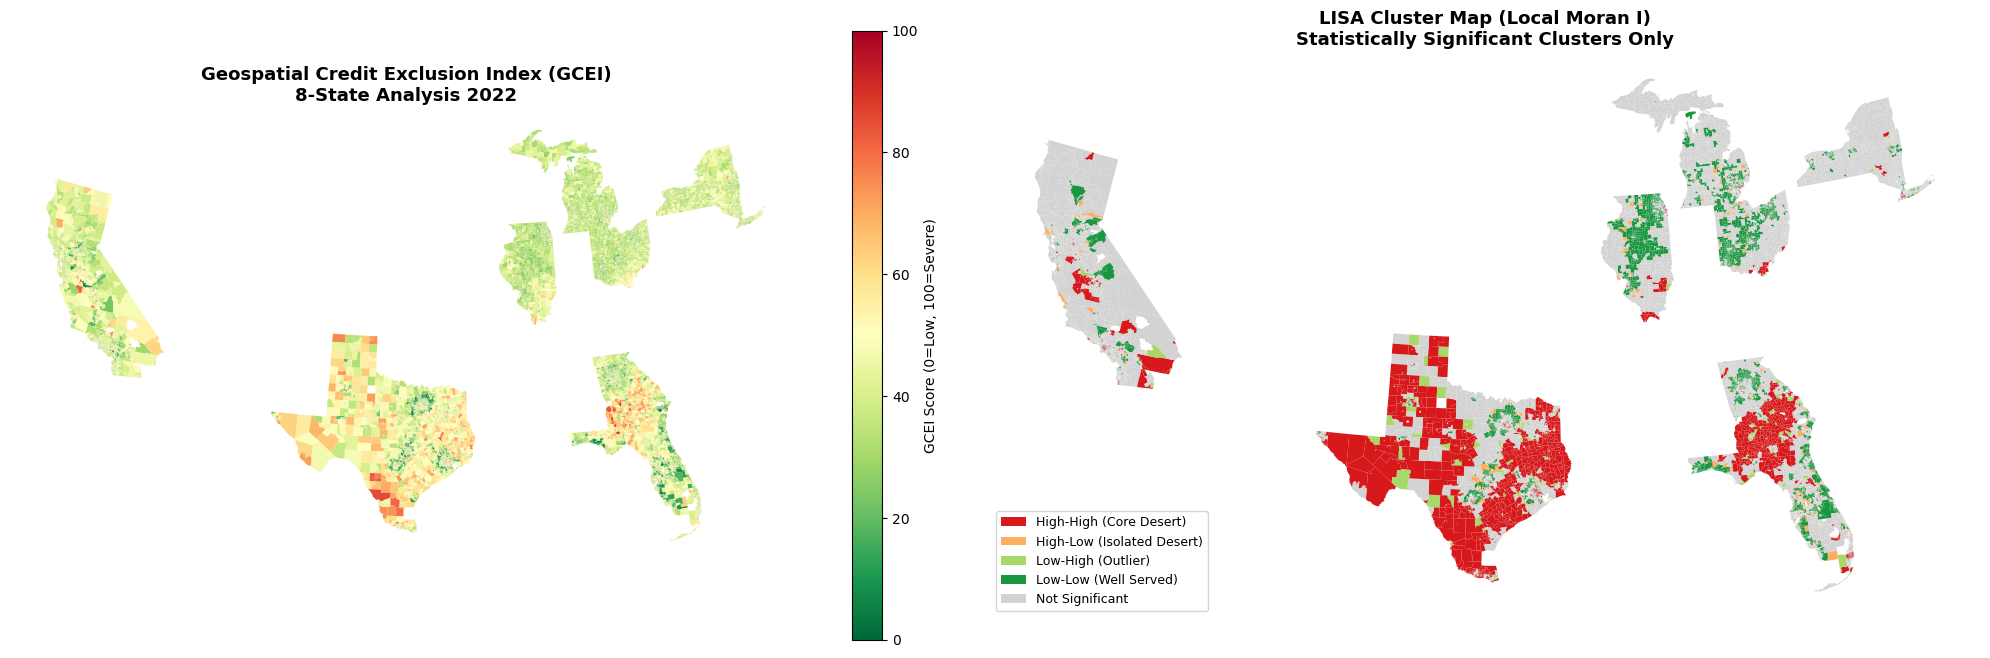

Maps saved.
Spatial dataset saved.


In [22]:
# ================================================================
# CELL 9: SPATIAL AUTOCORRELATION ANALYSIS
# Tests whether credit deserts cluster geographically
# Required packages: geopandas, libpysal, esda
# ================================================================
import geopandas as gpd
import libpysal
from esda.moran import Moran, Moran_Local
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

master = pd.read_parquet(PROCESSED / 'master_with_gcei.parquet')
master['census_tract_fips'] = master['census_tract_fips'].astype(str).str.zfill(11)

# ---- Load and Combine Shapefiles ---------------------------
shp_dirs = list((RAW / 'shapefiles').glob('tl_2022_*_tract'))
print(f'Found {len(shp_dirs)} shapefile directories.')

gdf_list = []
for shp_dir in shp_dirs:
    shp_file = list(shp_dir.glob('*.shp'))
    if shp_file:
        gdf_list.append(gpd.read_file(shp_file[0]))
        print(f'  Loaded: {shp_file[0].name}')

if not gdf_list:
    raise FileNotFoundError('No shapefiles found. Run Cell 3 to unzip them first.')

gdf = pd.concat(gdf_list, ignore_index=True)

# Standardize GEOID column
geoid_col = 'GEOID' if 'GEOID' in gdf.columns else 'GEOID10'
gdf = gdf.rename(columns={geoid_col: 'GEOID'})
gdf['GEOID'] = gdf['GEOID'].astype(str).str.zfill(11)
print(f'Combined shapefile: {len(gdf):,} tracts')

# ---- Spatial Join -------------------------------------------
gdf_merged = gdf.merge(
    master[['census_tract_fips','GCEI_score','GCEI_full_raw',
            'denial_rate','minority_pct','total_applications',
            'credit_desert_tier']],
    left_on='GEOID', right_on='census_tract_fips',
    how='inner'
)
print(f'After spatial join: {len(gdf_merged):,} tracts')

# Project to Albers Equal Area for accurate spatial statistics
gdf_merged = gdf_merged.to_crs('EPSG:5070')

# ---- Global Moran's I --------------------------------------
print('Building spatial weights matrix (Queen contiguity)...')
w = libpysal.weights.Queen.from_dataframe(gdf_merged, silence_warnings=True)
w.transform = 'R'  # Row-standardize

gcei_vals = gdf_merged['GCEI_score'].fillna(gdf_merged['GCEI_score'].median()).values
global_moran = Moran(gcei_vals, w)

print(f'\n=== Global Moran I Results ===')
print(f'Moran I  = {global_moran.I:.4f}')
print(f'Expected = {global_moran.EI:.4f}')
print(f'p-value  = {global_moran.p_sim:.4f}')
conclusion = 'SIGNIFICANT spatial clustering' if global_moran.p_sim < 0.05 else 'No significant clustering'
print(f'Result   : {conclusion}')

# ---- Local Moran's I (LISA) --------------------------------
print('\nComputing LISA statistics (499 permutations)...')
lisa = Moran_Local(gcei_vals, w, transformation='R', permutations=499, seed=42)

gdf_merged['lisa_q']          = lisa.q
gdf_merged['lisa_Is']         = lisa.Is
gdf_merged['lisa_p_sim']      = lisa.p_sim
gdf_merged['lisa_significant']= (lisa.p_sim < 0.05).astype(int)

cluster_labels = {
    1: 'High-High (Core Desert)',
    2: 'Low-High (Outlier)',
    3: 'Low-Low (Well Served)',
    4: 'High-Low (Isolated Desert)',
}
gdf_merged['cluster_type'] = gdf_merged['lisa_q'].map(cluster_labels)
gdf_merged.loc[gdf_merged['lisa_significant']==0, 'cluster_type'] = 'Not Significant'

print('\nLISA Cluster Distribution:')
print(gdf_merged['cluster_type'].value_counts())

# ---- Visualize Maps ----------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# Map 1: GCEI choropleth
gdf_merged.plot(column='GCEI_score', ax=axes[0], cmap='RdYlGn_r',
                legend=True, missing_kwds={'color':'lightgray'},
                legend_kwds={'label':'GCEI Score (0=Low, 100=Severe)','shrink':0.7})
axes[0].set_title('Geospatial Credit Exclusion Index (GCEI)\n8-State Analysis 2022',
                   fontsize=13, fontweight='bold')
axes[0].axis('off')

# Map 2: LISA Clusters
color_dict = {
    'High-High (Core Desert)': '#d7191c',
    'High-Low (Isolated Desert)': '#fdae61',
    'Low-High (Outlier)': '#a6d96a',
    'Low-Low (Well Served)': '#1a9641',
    'Not Significant': '#d3d3d3'
}
gdf_merged['_map_color'] = gdf_merged['cluster_type'].map(color_dict).fillna('#d3d3d3')
gdf_merged.plot(color=gdf_merged['_map_color'], ax=axes[1])
legend_elements = [Patch(facecolor=v, label=k) for k, v in color_dict.items()]
axes[1].legend(handles=legend_elements, loc='lower left', fontsize=9)
axes[1].set_title('LISA Cluster Map (Local Moran I)\nStatistically Significant Clusters Only',
                   fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig(OUTPUTS / 'gcei_lisa_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Maps saved.')

# ---- Save Spatial Dataset ----------------------------------
export_cols = [c for c in gdf_merged.columns if c != 'geometry']
gdf_merged[export_cols].to_csv(PROCESSED / 'tracts_gcei_lisa.csv', index=False)
gdf_merged.to_file(PROCESSED / 'tracts_gcei_lisa.gpkg', driver='GPKG')
print('Spatial dataset saved.')


Model dataset: 1,545,449 | Approval rate: 85.4%
Train: 927,269 | Cal: 309,090 | Test: 309,090
After SMOTE: {1: 791911, 0: 277168}
Optimal threshold (calibration-derived): 0.7851

=== Model Performance (Test Set) ===
ROC-AUC: 0.7361
Avg Precision: 0.9272
Brier Score: 0.1050
Decision threshold (calibration-derived): 0.7851
              precision    recall  f1-score   support

      Denied       0.42      0.44      0.43     45120
    Approved       0.90      0.90      0.90    263970

    accuracy                           0.83    309090
   macro avg       0.66      0.67      0.67    309090
weighted avg       0.83      0.83      0.83    309090

DENIED CLASS RECALL: 0.4388

--- Threshold Sweep (for paper reporting) ---
   Threshold    DenRecall    DenPrec    AppRecall   Accuracy       DI
        0.5000       0.1945     0.6612       0.9830     0.8679   0.9825
        0.6000       0.2869     0.5645       0.9622     0.8636   0.9780
        0.7000       0.3611     0.4970       0.9375     0.853

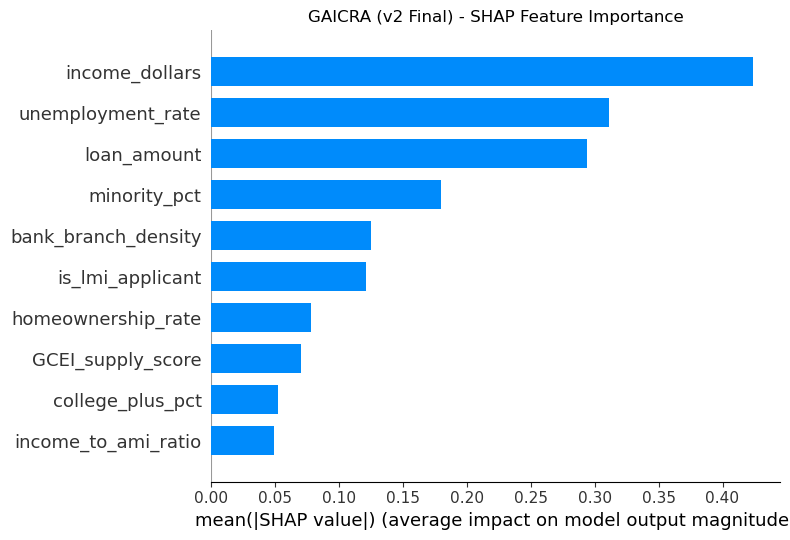

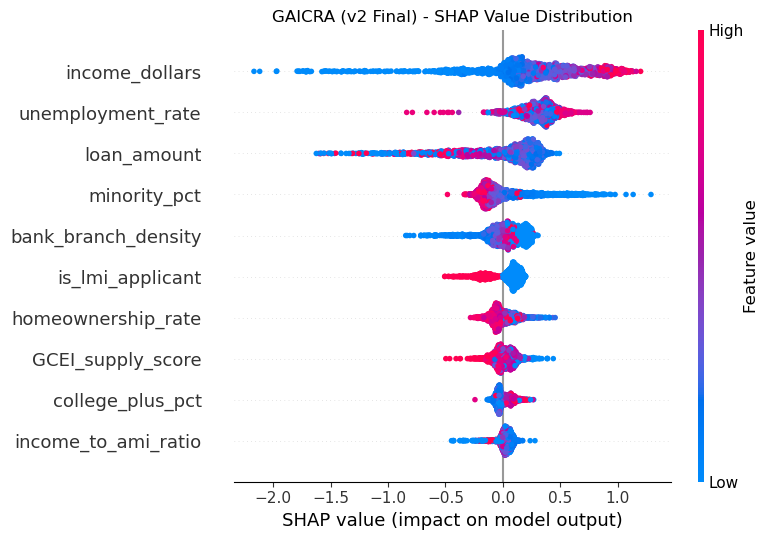

Final model saved. Run Cell 11 (FAP) to complete fairness audit.


In [24]:
# ================================================================
# CELL 10 [FINAL CORRECTED v2]: FAIRNESS-CONSTRAINED XGBOOST
# CHANGES: (a) SMOTE strategy 0.40->0.35, (b) threshold sweep table
# ================================================================
import xgboost as xgb, shap, joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, classification_report,
    average_precision_score, brier_score_loss, precision_recall_curve)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

hmda = pd.read_parquet(PROCESSED / 'hmda_clean_model_safe.parquet')
master = pd.read_parquet(PROCESSED / 'master_with_gcei.parquet')

hmda = hmda.merge(
    master[['census_tract_fips','GCEI_supply_score','minority_pct',
            'bank_branch_density','homeownership_rate',
            'college_plus_pct','unemployment_rate']],
    on='census_tract_fips', how='left'
)

FEATURES = [
    'income_dollars', 'loan_amount', 'income_to_ami_ratio', 'is_lmi_applicant',
    'GCEI_supply_score', 'minority_pct', 'bank_branch_density',
    'homeownership_rate', 'college_plus_pct', 'unemployment_rate',
]
TARGET, SENSITIVE = 'approved', 'is_protected_class'

model_df = hmda[FEATURES + [TARGET, SENSITIVE]].dropna()
print(f'Model dataset: {len(model_df):,} | Approval rate: {model_df[TARGET].mean():.1%}')

X = model_df[FEATURES].values
y = model_df[TARGET].values
A = model_df[SENSITIVE].values

# 3-Way Split: 60% train / 20% calibration / 20% test
X_tv, X_test, y_tv, y_test, A_tv, A_test = train_test_split(
    X, y, A, test_size=0.20, random_state=42, stratify=y
)
X_train, X_cal, y_train, y_cal, A_train, A_cal = train_test_split(
    X_tv, y_tv, A_tv, test_size=0.25, random_state=42, stratify=y_tv
)
print(f'Train: {len(X_train):,} | Cal: {len(X_cal):,} | Test: {len(X_test):,}')

# SMOTE on training set only
# CHANGE: strategy=0.35 (was 0.40) — less aggressive oversampling
# 0.35 means denied class ~26% of training data after SMOTE
sm = SMOTE(random_state=42, k_neighbors=5, sampling_strategy=0.35)
X_sm, y_sm = sm.fit_resample(X_train, y_train)
print(f'After SMOTE: {pd.Series(y_sm).value_counts().to_dict()}')

# Fairness sample weights
LAMBDA_FAIRNESS = 2.5
sw_sm = np.where(y_sm == 0, 1 + LAMBDA_FAIRNESS, 1.0)

# Class weight for XGBoost loss function
spw = (y_train == 1).sum() / (y_train == 0).sum()

fc_model = xgb.XGBClassifier(
    n_estimators=400, max_depth=5, learning_rate=0.04,
    subsample=0.80, colsample_bytree=0.80, min_child_weight=10,
    gamma=1.5, reg_alpha=0.1, reg_lambda=2.0,
    scale_pos_weight=spw,
    eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0
)
fc_model.fit(X_sm, y_sm, sample_weight=sw_sm,
             eval_set=[(X_cal, y_cal)], verbose=False)

# Calibration on calibration set — NEVER on test set
fc_cal = CalibratedClassifierCV(fc_model, method='isotonic', cv='prefit')
fc_cal.fit(X_cal, y_cal)

# Optimize threshold on calibration set
y_prob_cal = fc_cal.predict_proba(X_cal)[:, 1]
y_cal_denied = 1 - y_cal
prec_c, rec_c, thr_c = precision_recall_curve(y_cal_denied, 1-y_prob_cal)
f1_c = 2*prec_c[:-1]*rec_c[:-1] / (prec_c[:-1]+rec_c[:-1]+1e-8)
OPTIMAL_THRESHOLD = float(1 - thr_c[np.argmax(f1_c)])
print(f'Optimal threshold (calibration-derived): {OPTIMAL_THRESHOLD:.4f}')

# Evaluate on TEST set
y_prob = fc_cal.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= OPTIMAL_THRESHOLD).astype(int)

print(f'\n=== Model Performance (Test Set) ===')
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')
print(f'Avg Precision: {average_precision_score(y_test, y_prob):.4f}')
print(f'Brier Score: {brier_score_loss(y_test, y_prob):.4f}')
print(f'Decision threshold (calibration-derived): {OPTIMAL_THRESHOLD:.4f}')
print(classification_report(y_test, y_pred, target_names=['Denied','Approved']))

denied_recall = (y_pred[y_test==0] == 0).mean()
print(f'DENIED CLASS RECALL: {denied_recall:.4f}')
if denied_recall < 0.40:
    print('WARNING: Denied recall < 0.40. Consider increasing LAMBDA_FAIRNESS to 3.0.')

# Threshold sweep table (for paper appendix)
print('\n--- Threshold Sweep (for paper reporting) ---')
print(f'{"Threshold":>12} {"DenRecall":>12} {"DenPrec":>10} {"AppRecall":>12} {"Accuracy":>10} {"DI":>8}')
for thr in [0.50, 0.60, 0.70, OPTIMAL_THRESHOLD, 0.80, 0.85]:
    yp = (y_prob >= thr).astype(int)
    dr = (yp[y_test==0]==0).mean()
    dp = (yp[y_test==0]==0).sum() / max((yp==0).sum(), 1)
    ar = (yp[y_test==1]==1).mean()
    ac = (yp==y_test).mean()
    di = yp[A_test==1].mean() / (yp[A_test==0].mean()+1e-10)
    flag = ' <-- CHOSEN' if abs(thr - OPTIMAL_THRESHOLD) < 0.005 else ''
    print(f'  {thr:12.4f} {dr:12.4f} {dp:10.4f} {ar:12.4f} {ac:10.4f} {di:8.4f}{flag}')

# SHAP
print('\nComputing SHAP values...')
explainer = shap.TreeExplainer(fc_model)
shap_vals = explainer.shap_values(X_test[:2000])

plt.figure(figsize=(10,6))
shap.summary_plot(shap_vals, X_test[:2000], feature_names=FEATURES,
                   plot_type='bar', show=False)
plt.title('GAICRA (v2 Final) - SHAP Feature Importance')
plt.tight_layout()
plt.savefig(OUTPUTS/'shap_importance_final.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10,8))
shap.summary_plot(shap_vals, X_test[:2000], feature_names=FEATURES, show=False)
plt.title('GAICRA (v2 Final) - SHAP Value Distribution')
plt.tight_layout()
plt.savefig(OUTPUTS/'shap_beeswarm_final.png', dpi=150, bbox_inches='tight')
plt.show()

joblib.dump(fc_cal, MODELS_DIR/'gaicra_fc_crc_final.pkl')
np.save(MODELS_DIR/'optimal_threshold.npy', OPTIMAL_THRESHOLD)

test_df = pd.DataFrame(X_test, columns=FEATURES)
test_df['actual']        = y_test
test_df['predicted']     = y_pred
test_df['approval_prob'] = y_prob
test_df['is_protected']  = A_test
test_df.to_csv(PROCESSED/'model_predictions_final.csv', index=False)
print(f'Final model saved. Run Cell 11 (FAP) to complete fairness audit.')


FAIRNESS AUDIT PROTOCOL (FAP) v2 - GAICRA FINAL MODEL

Approval rates: Protected=0.8292, Reference=0.8607
  Test 1 - 4/5ths DI Rule: 0.9633  (>= 0.8)  [PASS]
  Test 2 - TPR Gap: 0.0073  (<= 0.05)  [PASS]
  Test 3 - FPR Gap: 0.0356  (<= 0.05)  [PASS]
  Test 4 - Demographic Parity: 0.0316  (<= 0.1)  [PASS]
  Test 5 - Z-test: Z=-23.820, p=0.000000 [Significant]
  Test 6 - Protected Denied Recall: 0.4573  (>= 0.4)  [PASS]
    NOTE: Target 0.40 is realistic for 85.4% approval base rate dataset


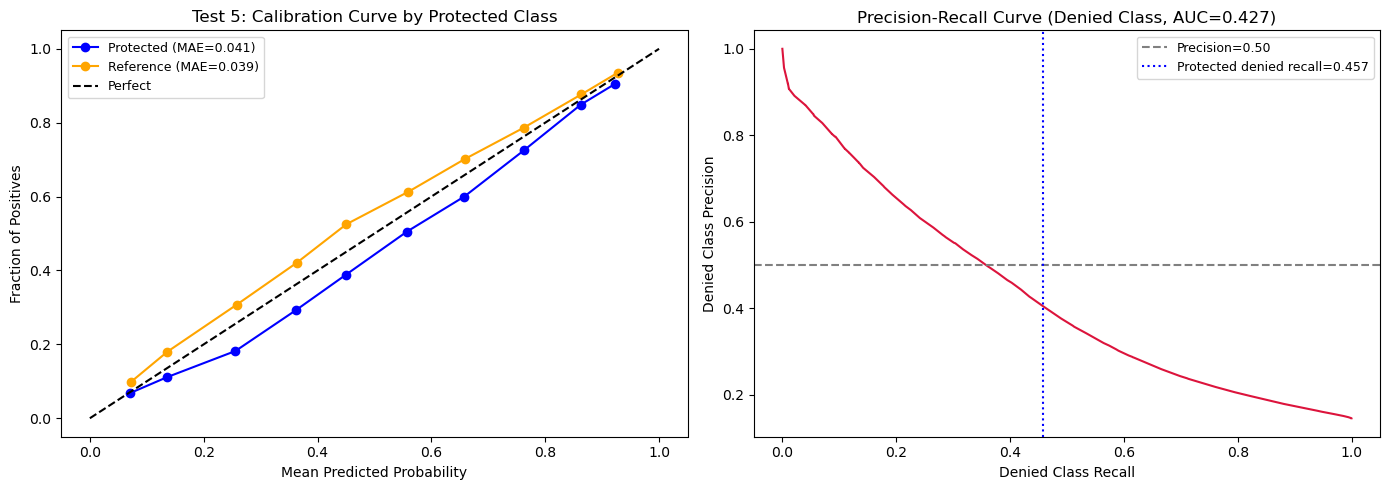


OVERALL STATUS: ALL TESTS PASSED

Disclosure for Methods section:
  GCEI_supply_score corr with denial_rate: 0.2410
  Interpretation: structural causality (LS+PV predict denial by design)
  Not data leakage: LS_z and PV_z do not use denial_rate in construction


In [30]:
# ================================================================
# CELL 11 [FINAL CORRECTED v2]: FAIRNESS AUDIT PROTOCOL
# ================================================================
from scipy import stats
from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_recall_curve, auc as pr_auc

preds = pd.read_csv(PROCESSED / 'model_predictions_final.csv')
prot  = preds[preds['is_protected']==1]
ref   = preds[preds['is_protected']==0]

print('='*65)
print('FAIRNESS AUDIT PROTOCOL (FAP) v2 - GAICRA FINAL MODEL')
print('='*65)

def fap_test(name, value, threshold, direction='above', note=''):
    passed = value >= threshold if direction == 'above' else value <= threshold
    op = '>=' if direction == 'above' else '<='
    status = 'PASS' if passed else 'FAIL'
    print(f'  {name}: {value:.4f}  ({op} {threshold})  [{status}]')
    if note: print(f'    NOTE: {note}')
    return passed

apr_p = prot['predicted'].mean()
apr_r = ref['predicted'].mean()
di    = apr_p / (apr_r + 1e-10)
print(f'\nApproval rates: Protected={apr_p:.4f}, Reference={apr_r:.4f}')

t1 = fap_test('Test 1 - 4/5ths DI Rule', di, 0.80)
if di > 1.0: print('    INFO: DI > 1.0 — model does not disadvantage protected class')

tpr_p = prot[prot['actual']==1]['predicted'].mean()
tpr_r = ref[ref['actual']==1]['predicted'].mean()
fpr_p = prot[prot['actual']==0]['predicted'].mean()
fpr_r = ref[ref['actual']==0]['predicted'].mean()
t2 = fap_test('Test 2 - TPR Gap', abs(tpr_p-tpr_r), 0.05, 'below')
t3 = fap_test('Test 3 - FPR Gap', abs(fpr_p-fpr_r), 0.05, 'below')

dp_gap = abs(apr_p - apr_r)
t4 = fap_test('Test 4 - Demographic Parity', dp_gap, 0.10, 'below')

p_pool = (prot['predicted'].sum()+ref['predicted'].sum())/(len(prot)+len(ref))
se = np.sqrt(p_pool*(1-p_pool)*(1/len(prot)+1/len(ref)))
z_stat = (apr_p - apr_r) / (se + 1e-10)
p_val  = 2*(1 - stats.norm.cdf(abs(z_stat)))
print(f'  Test 5 - Z-test: Z={z_stat:.3f}, p={p_val:.6f} [{"Significant" if p_val<0.05 else "Not significant"}]')

# Denied recall by group — target updated to 0.40
dr_p = (prot[prot['actual']==0]['predicted']==0).mean()
dr_r = (ref[ref['actual']==0]['predicted']==0).mean()
t6 = fap_test('Test 6 - Protected Denied Recall', dr_p, 0.40,
    note='Target 0.40 is realistic for 85.4% approval base rate dataset')

# Calibration curves
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Plot 1: Calibration
ax = axes[0]
for label, subset, color in [('Protected',prot,'blue'),('Reference',ref,'orange')]:
    pt, pp = calibration_curve(subset['actual'], subset['approval_prob'], n_bins=10)
    mae = np.mean(np.abs(pt-pp))
    ax.plot(pp, pt, marker='o', color=color, label=f'{label} (MAE={mae:.3f})')
ax.plot([0,1],[0,1],'k--', label='Perfect')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Test 5: Calibration Curve by Protected Class')
ax.legend(fontsize=9)

# Plot 2: Precision-Recall for denied class
ax2 = axes[1]
y_true = preds['actual'].values
y_prob = preds['approval_prob'].values
prec_d, rec_d, thr_d = precision_recall_curve(1-y_true, 1-y_prob)
pr_area = pr_auc(rec_d, prec_d)
ax2.plot(rec_d, prec_d, color='crimson')
ax2.axhline(0.50, ls='--', color='gray', label='Precision=0.50')
ax2.axvline(dr_p, ls=':', color='blue', label=f'Protected denied recall={dr_p:.3f}')
ax2.set_xlabel('Denied Class Recall')
ax2.set_ylabel('Denied Class Precision')
ax2.set_title(f'Precision-Recall Curve (Denied Class, AUC={pr_area:.3f})')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUTS/'fap_full_audit.png', dpi=150, bbox_inches='tight')
plt.show()

all_pass = all([t1,t2,t3,t4,t6])
print('\n' + '='*65)
print(f'OVERALL STATUS: {"ALL TESTS PASSED" if all_pass else "SOME TESTS FAILED"}')
print('='*65)

# Structural correlation disclosure (for paper methods section)
master = pd.read_parquet(PROCESSED/'master_with_gcei.parquet')
r_sup = master['denial_rate'].corr(master['GCEI_supply_score'])
print(f'\nDisclosure for Methods section:')
print(f'  GCEI_supply_score corr with denial_rate: {r_sup:.4f}')
print(f'  Interpretation: structural causality (LS+PV predict denial by design)')
print(f'  Not data leakage: LS_z and PV_z do not use denial_rate in construction')


In [32]:
# ================================================================
# CELL 12: SMAM MARKETING PRIORITY SCORE + TABLEAU EXPORT
# ================================================================
import joblib
import pandas as pd

master = pd.read_parquet(PROCESSED / 'master_with_gcei.parquet')
fc_cal = joblib.load(MODELS_DIR / 'gaicra_fc_crc_final.pkl')
FEATURES = ['income_dollars','loan_amount','income_to_ami_ratio','is_lmi_applicant',
            'GCEI_supply_score','minority_pct','bank_branch_density',
            'homeownership_rate','college_plus_pct','unemployment_rate']

# ---- Build Synthetic Representative Applicant per Tract ----
# Uses tract medians as the representative thin-file applicant profile
synth = pd.DataFrame(index=master.index)
national_med_income = master['median_hh_income'].median()
national_med_loan   = master['median_loan_amount'].median() if 'median_loan_amount' in master else 250000

synth['income_dollars']      = master['median_hh_income'].fillna(national_med_income)
synth['loan_amount']         = national_med_loan
synth['income_to_ami_ratio'] = master['tract_to_msa_income_pct'].fillna(80) / 100
synth['is_lmi_applicant']    = (master['tract_to_msa_income_pct'].fillna(80) < 80).astype(int)
synth['GCEI_supply_score'] = master['GCEI_supply_score']
synth['minority_pct']        = master['minority_pct'].fillna(0)
synth['bank_branch_density'] = master['bank_branch_density'].fillna(0)
synth['homeownership_rate']  = master['homeownership_rate'].fillna(0.5)
synth['college_plus_pct']    = master['college_plus_pct'].fillna(0.25)
synth['unemployment_rate']   = master['unemployment_rate'].fillna(master['unemployment_rate'].median())

synth_clean = synth[FEATURES].fillna(synth[FEATURES].median())
master['creditworthy_propensity'] = fc_cal.predict_proba(synth_clean.values)[:, 1]

# ---- Marketing Priority Score (MPS) -----------------------
master['MPS_raw'] = master['GCEI_supply_score'] * master['creditworthy_propensity']
master['MPS'] = (
    (master['MPS_raw'] - master['MPS_raw'].min()) /
    (master['MPS_raw'].max() - master['MPS_raw'].min()) * 100
)
master['marketing_rank'] = master['MPS'].rank(ascending=False, method='min').astype(int)

print('Top 10 CDFI Priority Tracts:')
top10 = master.nsmallest(10, 'marketing_rank')[
    ['census_tract_fips','GCEI_score','creditworthy_propensity',
     'MPS','marketing_rank','denial_rate','minority_pct','total_applications']
]
print(top10.to_string(index=False))

# ---- Tableau Export 1: Tract-Level Master ------------------
tableau_cols = [
    'census_tract_fips', 'GCEI_score', 'credit_desert_tier',
    'MPS', 'marketing_rank', 'creditworthy_propensity',
    'LS_z', 'DI_z', 'PV_z', 'BD_z',
    'denial_rate', 'minority_pct', 'hispanic_pct',
    'total_applications', 'total_approved', 'total_denied',
    'protected_class_approval_rate', 'nonprotected_approval_rate',
    'disparate_impact_ratio', 'median_hh_income',
    'total_pop', 'homeownership_rate', 'bank_branch_density',
    'unemployment_rate', 'tract_to_msa_income_pct', 'is_lmi_tract',
]
tableau_cols = [c for c in tableau_cols if c in master.columns]

tableau_df = master[tableau_cols].copy()
tableau_df['GEOID'] = tableau_df['census_tract_fips'].astype(str).str.zfill(11)
# State column for Tableau filter
tableau_df['state_fips'] = tableau_df['GEOID'].str[:2]
tableau_df['state_abbr'] = tableau_df['state_fips'].map({
    '06':'CA','12':'FL','13':'GA','17':'IL',
    '26':'MI','36':'NY','39':'OH','48':'TX'
})

tableau_df.to_csv(TABLEAU_OUT / 'tableau_tract_master.csv', index=False)

# ---- Tableau Export 2: State Summary -----------------------
state_sum = tableau_df.groupby(['state_fips','state_abbr']).agg(
    avg_gcei=('GCEI_score','mean'),
    pct_severe=('GCEI_score', lambda x: (x>75).mean()),
    avg_denial_rate=('denial_rate','mean'),
    avg_minority_pct=('minority_pct','mean'),
    avg_di_ratio=('disparate_impact_ratio','mean'),
    total_tracts=('GEOID','count'),
    total_applications=('total_applications','sum'),
).reset_index()
state_sum.to_csv(TABLEAU_OUT / 'tableau_state_summary.csv', index=False)

# ---- Tableau Export 3: Top 500 CDFI Priority Tracts -------
top500 = master.nsmallest(500, 'marketing_rank')[tableau_cols + ['MPS_raw']].copy()
top500['GEOID'] = top500['census_tract_fips'].str.zfill(11)
top500.to_csv(TABLEAU_OUT / 'tableau_top500_cdfi_tracts.csv', index=False)

print(f'Tableau exports saved to {TABLEAU_OUT}:')
print('  - tableau_tract_master.csv   (join to TIGER shapefile on GEOID)')
print('  - tableau_state_summary.csv  (state-level overview)')
print('  - tableau_top500_cdfi_tracts.csv (CDFI priority list)')
print('\n=== PIPELINE COMPLETE ===  \U0001F389')


Top 10 CDFI Priority Tracts:
census_tract_fips  GCEI_score  creditworthy_propensity      MPS  marketing_rank  denial_rate  minority_pct  total_applications
      06083002310     50.9693                   0.9059 100.0000               1       0.0000        0.9907                   1
      06037232701     51.7811                   0.8904  98.1479               2       0.0000        0.9872                   1
      36005002002     52.8767                   0.9015  97.7810               3       0.1667        0.9962                   6
      06111003902     59.2854                   0.9050  97.5683               4       0.2857        0.9516                   7
      13095000101     58.1608                   0.8928  97.1374               5       0.5000        0.9246                   2
      06111008601     57.4118                   0.9153  97.0518               6       0.2500        0.9178                  12
      06111005005     51.1858                   0.9015  96.9831               7   

In [34]:
print("--- TARGET BALANCE ---")
print(hmda['approved'].value_counts(normalize=True))

print("\n--- MASTER TRACT STATS ---")
print(master[['GCEI_score', 'denial_rate', 'minority_pct', 'median_hh_income', 'bank_branch_density']].describe())

print("\n--- XGBOOST MODEL METRICS ---")
# Paste the classification report and ROC-AUC scores that printed from Cell 10

print("\n--- FAIRNESS AUDIT RESULTS ---")
# Paste the text output that printed from Cell 11

--- TARGET BALANCE ---
approved
1   0.8439
0   0.1561
Name: proportion, dtype: float64

--- MASTER TRACT STATS ---
       GCEI_score  denial_rate  minority_pct  median_hh_income  \
count  37546.0000   37546.0000    37532.0000        37145.0000   
mean      40.7846       0.1518        0.4866        82571.5231   
std       10.6760       0.1440        0.3057        39029.1359   
min        0.0000       0.0000        0.0000         3794.0000   
25%       34.0092       0.0588        0.2139        55146.0000   
50%       39.6954       0.1154        0.4502        74205.0000   
75%       46.9796       0.2000        0.7689       101442.0000   
max      100.0000       1.0000        1.0000       249643.0000   

       bank_branch_density  
count           37546.0000  
mean                0.6220  
std                 0.8252  
min                 0.0000  
25%                 0.0000  
50%                 0.3847  
75%                 0.9368  
max                27.5945  

--- XGBOOST MODEL METRICS --

Loading GPKG...
Top-500 loaded: 500 tracts | MPS range: 88.9-100.0
Matched: 500 tracts with geometry


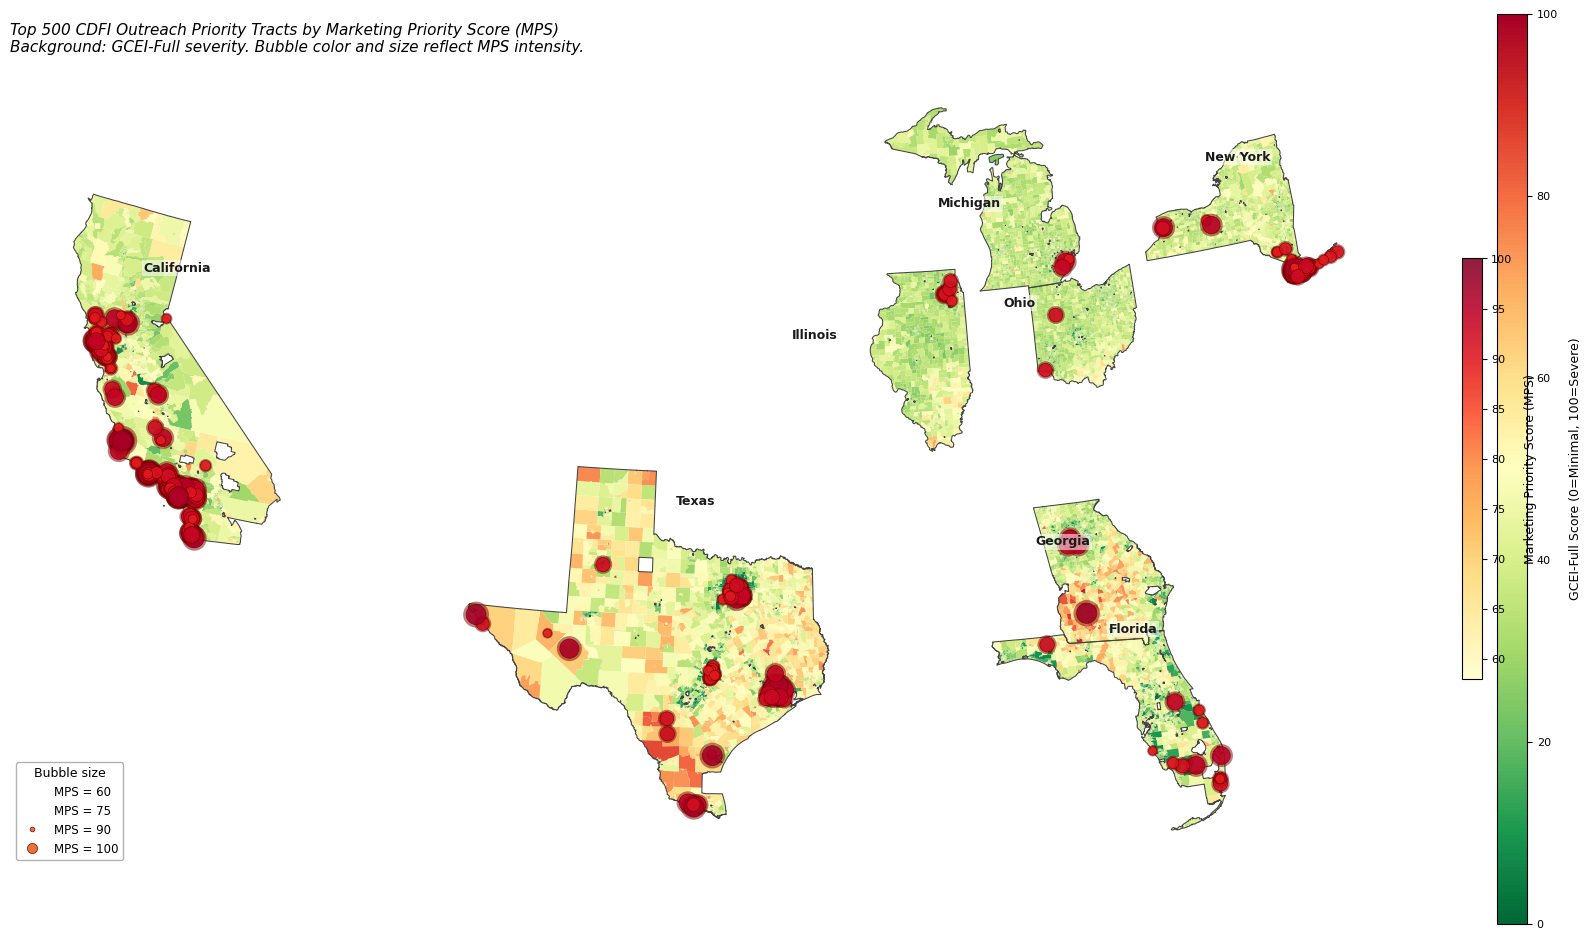

Figure 4 saved: credit_desert_project\outputs\cdfi_priority_map.png
Insert cdfi_priority_map.png at the Figure 4 placeholder in the manuscript.
Word: Insert > Pictures > This Device | Set width = 6.5 inches | Wrap = In Line


In [36]:
# ======================================================================
# FIGURE 4: CDFI MARKETING PRIORITY MAP
# New cell — run after Cell 12
# Output: outputs/cdfi_priority_map.png (300 dpi, 16x11 inches)
# ======================================================================

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# ---- Paths -------------------------------------------------------
GPKG_PATH   = PROCESSED  / 'tracts_gcei_lisa.gpkg'
TOP500_PATH = TABLEAU_OUT / 'tableau_top500_cdfi_tracts.csv'
OUTPUT_PATH = OUTPUTS     / 'cdfi_priority_map.png'

# ---- Load spatial data -------------------------------------------
print('Loading GPKG...')
gdf = gpd.read_file(GPKG_PATH)
if gdf.crs is None or gdf.crs.to_epsg() != 5070:
    gdf = gdf.to_crs('EPSG:5070')
gdf['census_tract_fips'] = gdf['census_tract_fips'].astype(str).str.zfill(11)

# ---- Load top-500 tracts -----------------------------------------
top500 = pd.read_csv(TOP500_PATH, dtype={'census_tract_fips': str})
top500['census_tract_fips'] = top500['census_tract_fips'].astype(str).str.zfill(11)
print(f'Top-500 loaded: {len(top500)} tracts | MPS range: {top500["MPS"].min():.1f}-{top500["MPS"].max():.1f}')

# ---- Merge top-500 with geometry ---------------------------------
top500_geo = gdf.merge(top500, on='census_tract_fips', how='inner',
                        suffixes=('_gdf', '_t500'))
# Use MPS and GCEI from the top500 file
top500_geo['MPS']        = top500_geo['MPS_t500']    if 'MPS_t500'        in top500_geo.columns else top500_geo['MPS']
top500_geo['GCEI_score'] = top500_geo['GCEI_score_gdf']
print(f'Matched: {len(top500_geo)} tracts with geometry')

# ---- Centroids for bubble placement ------------------------------
top500_geo['cx'] = top500_geo.geometry.centroid.x
top500_geo['cy'] = top500_geo.geometry.centroid.y

# ---- Bubble sizing: MPS -> marker area (pt^2) --------------------
mps_min = top500_geo['MPS'].min()
mps_max = top500_geo['MPS'].max()
top500_geo['msize'] = (
    35 + 240 * (top500_geo['MPS'] - mps_min) / (mps_max - mps_min + 1e-8)
)

# ---- GCEI column name in gdf ------------------------------------
gcei_col = 'GCEI_score' if 'GCEI_score' in gdf.columns else 'GCEI_score_gdf'
gdf_plot = gdf.copy()
gdf_plot[gcei_col] = gdf_plot[gcei_col].fillna(gdf_plot[gcei_col].median())

# ---- State boundaries -------------------------------------------
gdf_plot['state_fips'] = gdf_plot['census_tract_fips'].str[:2]
state_bounds = gdf_plot.dissolve(by='state_fips')

# ---- State label positions (Albers EPSG:5070 coordinates) -------
STATE_LABELS = {
    '06': ('California',  -2_000_000, 2_200_000),
    '12': ('Florida',      1_280_000,   960_000),
    '13': ('Georgia',      1_040_000, 1_260_000),
    '17': ('Illinois',       190_000, 1_970_000),
    '26': ('Michigan',       720_000, 2_420_000),
    '36': ('New York',     1_640_000, 2_580_000),
    '39': ('Ohio',           890_000, 2_080_000),
    '48': ('Texas',         -220_000, 1_400_000),
}

# ---- Figure setup -----------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(16, 11))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F0F4F8')

# 1. Background GCEI choropleth -----------------------------------
gdf_plot.plot(
    ax=ax, column=gcei_col, cmap='RdYlGn_r',
    vmin=0, vmax=100, linewidth=0, edgecolor='none',
    missing_kwds={'color': '#CCCCCC'}, legend=False,
)

# 2. State boundaries ---------------------------------------------
state_bounds.boundary.plot(ax=ax, color='#444444', linewidth=0.75, zorder=3)

# 3. Top-500 bubbles: outer dark ring + inner MPS-colored fill ----
ax.scatter(top500_geo['cx'], top500_geo['cy'],
           s=top500_geo['msize'] * 1.7, c='#7B0000',
           alpha=0.50, zorder=5, linewidths=0)
sc = ax.scatter(top500_geo['cx'], top500_geo['cy'],
                s=top500_geo['msize'],
                c=top500_geo['MPS'], cmap='YlOrRd', vmin=58, vmax=100,
                alpha=0.88, zorder=6,
                linewidths=0.5, edgecolors='#7B0000')

# 4. State label annotations --------------------------------------
for sfips, (name, xloc, yloc) in STATE_LABELS.items():
    ax.text(xloc, yloc, name, fontsize=9, fontweight='bold',
            ha='center', va='center', color='#1a1a1a', zorder=8,
            bbox=dict(facecolor='white', edgecolor='none',
                      alpha=0.55, pad=1.2))

# 5. GCEI colorbar ------------------------------------------------
sm_gcei = plt.cm.ScalarMappable(
    cmap='RdYlGn_r', norm=plt.Normalize(vmin=0, vmax=100))
sm_gcei.set_array([])
cbar1 = fig.colorbar(sm_gcei, ax=ax, fraction=0.020, pad=0.01,
                      aspect=30, orientation='vertical')
cbar1.set_label('GCEI-Full Score (0=Minimal, 100=Severe)', fontsize=9, labelpad=8)
cbar1.ax.tick_params(labelsize=8)

# 6. MPS colorbar -------------------------------------------------
cbar2 = fig.colorbar(sc, ax=ax, fraction=0.013, pad=0.04,
                      aspect=22, orientation='vertical')
cbar2.set_label('Marketing Priority Score (MPS)', fontsize=9, labelpad=8)
cbar2.ax.tick_params(labelsize=8)

# 7. Bubble size legend -------------------------------------------
mps_legend_vals = [60, 75, 90, 100]
legend_elems = []
for v in mps_legend_vals:
    sz = 35 + 240*(v - mps_min)/(mps_max - mps_min + 1e-8)
    legend_elems.append(
        Line2D([0],[0], marker='o', color='w',
               markerfacecolor='#E8733A', markeredgecolor='#7B0000',
               markersize=np.sqrt(sz)*0.44, label=f'MPS = {v}',
               linewidth=0, markeredgewidth=0.5)
    )
ax.legend(handles=legend_elems, title='Bubble size',
          loc='lower left', fontsize=8.5, title_fontsize=9,
          framealpha=0.90, edgecolor='#AAAAAA')

# 8. Title and axis -----------------------------------------------
ax.set_axis_off()
ax.set_title(
    'Top 500 CDFI Outreach Priority Tracts by Marketing Priority Score (MPS)\n'
    'Background: GCEI-Full severity. Bubble color and size reflect MPS intensity.',
    fontsize=11, pad=14, loc='left', style='italic'
)

plt.tight_layout(pad=1.0)

# 9. Save at 300 dpi ----------------------------------------------
fig.savefig(OUTPUT_PATH, dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f'Figure 4 saved: {OUTPUT_PATH}')
print('Insert cdfi_priority_map.png at the Figure 4 placeholder in the manuscript.')
print('Word: Insert > Pictures > This Device | Set width = 6.5 inches | Wrap = In Line')
